# ValidMind + Databricks Quickstart

This notebook validates that the ValidMind Library works correctly within a Databricks Collaborative Notebook environment. It demonstrates:

- Installing and initializing the ValidMind Library
- Loading data from a Unity Catalog table via Spark
- Training a simple classification model
- Running ValidMind tests and sending results to the ValidMind Platform

## Before you begin

You will need:
1. A running Databricks workspace with Unity Catalog enabled
2. A ValidMind account with a registered model
3. Your ValidMind API credentials (API key, API secret, model identifier)

To get your credentials: log in to ValidMind → **Model Inventory** → select your model → **Getting Started** → **Copy snippet to clipboard**.

> **Note:** If you don't have a UC table ready, this notebook includes a fallback that generates synthetic data so you can still validate the full workflow.

## Step 1 — Install the ValidMind Library

Run this cell first. Databricks requires a Python restart after `%pip install`.

In [1]:
%pip install -q validmind


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Restart Python kernel to pick up newly installed packages
dbutils.library.restartPython()

NameError: name 'dbutils' is not defined

## Step 2 — Verify installation

In [3]:
import importlib.metadata
version = importlib.metadata.version('validmind')
print(f'ValidMind Library version: {version}')
print('Installation successful!')

ValidMind Library version: 2.12.5
Installation successful!


## Step 3 — Initialize the ValidMind Library

Replace the placeholder values below with your actual credentials from the ValidMind Platform.

For local development, use `http://localhost:5000/api/v1/tracking` as the `api_host`.
For production, use `https://app.prod.validmind.ai/api/v1/tracking/tracking`.

In [4]:
import validmind as vm

vm.init(
    api_host="http://localhost:5000/api/v1/tracking",
    api_key="935442be7a5b9ac5e1aaff5f91174696",
    api_secret="ce822de88d8b69fdd4f96906b450e8d37cc0d85682117feb1693c099e9376fac",
    model="cmlgyjftq00052fp24yztwo2i",
)

2026-04-20 08:59:08,869 - ERROR(validmind.api_client): Future releases will require `document` as one of the options you must provide to `vm.init()`. To learn more, refer to https://docs.validmind.ai/developer/validmind-library.html
2026-04-20 08:59:08,913 - INFO(validmind.api_client): 🎉 Connected to ValidMind!
📊 Model: test new model (ID: cmlgyjftq00052fp24yztwo2i)
📁 Document Type: validation_report


## Step 4 — Load data from your linked Databricks table

Instead of querying Databricks directly, this notebook loads data through ValidMind.
ValidMind fetches and syncs the Unity Catalog table data when you create a binding in
**Settings → Integrations → Databricks**, so the same dataset is available here via the
tracking API — no Spark session or direct UC credentials needed.

**Prerequisites:**
1. A Databricks integration configured in ValidMind Settings
2. A `table` binding created for this model (link a Unity Catalog table to this model)
3. At least one successful sync (the initial sync triggers automatically on binding creation)

If no binding exists yet, set `USE_SYNTHETIC_FALLBACK = True` to run with generated data.

In [39]:
import requests
import pandas as pd
from validmind import api_client as _vm_client

# Set to True only if you don't have a Databricks table binding set up yet
USE_SYNTHETIC_FALLBACK = False

# ---------------------------------------------------------------------------
# Load from ValidMind — uses the linked Databricks table binding for this model
# ---------------------------------------------------------------------------
if not USE_SYNTHETIC_FALLBACK:
    _api_host = _vm_client.get_api_host()  # same host as vm.init()
    _headers  = _vm_client._get_api_headers()

    _response = requests.get(
        f"{_api_host}/integrations/dataset",
        headers=_headers,
        timeout=30,
    )

    if _response.status_code == 200:
        _data = _response.json()
        TABLE_NAME    = _data.get("table_name", "unknown")
        TARGET_COLUMN = "target"  # <-- update if your table uses a different column name
        row_data      = _data.get("row_data", [])

        if not row_data:
            raise RuntimeError(
                f"Binding found for table '{TABLE_NAME}' but row_data is empty. "
                "The sync may still be in progress — wait a moment and re-run this cell."
            )

        df = pd.DataFrame(row_data)

        if TARGET_COLUMN not in df.columns:
            raise ValueError(
                f"Column '{TARGET_COLUMN}' not found in synced data. "
                f"Available columns: {list(df.columns)}. "
                "Update TARGET_COLUMN above to match your table's target column."
            )

        print(f"Loaded {len(df):,} rows, {len(df.columns)} columns from {TABLE_NAME}")
        print(f"Last synced: {_data.get('last_synced_at', 'unknown')}")
        print(f"Target distribution: {df[TARGET_COLUMN].value_counts().to_dict()}")
        display(df.head())

    elif _response.status_code == 404:
        raise RuntimeError(
            "No active Databricks table binding found for this model.\n\n"
            "To fix:\n"
            "  1. Go to ValidMind → Settings → Integrations → Databricks\n"
            "  2. Open the model binding browser and select a Unity Catalog table\n"
            "  3. Wait ~30 seconds for the initial sync to complete\n"
            "  4. Re-run this cell\n\n"
            "Or set USE_SYNTHETIC_FALLBACK = True above to continue with generated data."
        )
    else:
        raise RuntimeError(
            f"Unexpected error loading dataset from ValidMind: "
            f"{_response.status_code} — {_response.text}"
        )

Loaded 2,000 rows, 11 columns from workspace.default.validmind_sample
Last synced: 2026-04-20T17:32:04.754093+00:00
Target distribution: {'1': 1000, '0': 1000}


,age,target,tenure,balance,geo_encoded,credit_score,num_products,gender_encoded,has_credit_card,estimated_salary,is_active_member
0,1.0449752534369274,1,0.6952927266643856,4.547093922936896,-1.8702084671204506,-3.2304853248640137,0.7099476037002423,7.149388996534131,-2.873270380215682,1.1974231998049074,1.622875273590974
1,-0.02784269907846426,0,0.4918144010879626,-0.9046053315584104,-0.8483194056261063,-0.9694567772480727,0.09575115669485841,0.03961306914371143,1.0473431163438045,-0.8571723738917058,-0.8382832367759102
2,-1.9917872350511119,0,-0.4578169695901857,-0.40706986175941995,-1.2511538337688415,-0.23342484254422935,-2.2213623912202762,0.16537623719369912,-2.598014189473973,-0.5791288370068761,0.8579892971621974
3,1.005994457740662,0,-1.276618200244661,-2.529162161513636,0.509018910577683,-1.7468422838745599,-1.5375753495480535,2.2544633490237804,-2.303886235302519,-0.7483831806910334,-0.13331127234599705
4,-1.5318129494044341,1,1.791782273613359,0.7295423277633509,1.2367380983245346,-1.0038508113282965,0.1895831515529864,-0.5297722396450917,-0.5491428842044095,-1.316862269378586E-4,1.4221579721661985


In [ ]:
# ---------------------------------------------------------------------------
# Synthetic data fallback — runs when USE_SYNTHETIC_FALLBACK = True
# Uses the Bank Customer Churn dataset pattern from ValidMind examples
# ---------------------------------------------------------------------------
if USE_SYNTHETIC_FALLBACK:
    import numpy as np
    from sklearn.datasets import make_classification

    np.random.seed(42)
    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=6,
        n_redundant=2,
        random_state=42,
    )
    feature_names = [
        "credit_score", "age", "tenure", "balance",
        "num_products", "has_credit_card", "is_active_member",
        "estimated_salary", "geography_encoded", "gender_encoded",
    ]
    df = pd.DataFrame(X, columns=feature_names)
    df["target"] = y
    TARGET_COLUMN = "target"
    TABLE_NAME    = "synthetic"

    print(f"Using synthetic dataset: {len(df):,} rows, {len(df.columns)} columns")
    print(f"Target distribution: {df[TARGET_COLUMN].value_counts().to_dict()}")
    display(df.head())

## Step 5 — Prepare train/test split

In [29]:
from sklearn.model_selection import train_test_split

feature_columns = [c for c in df.columns if c != TARGET_COLUMN]

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f'Train set: {len(train_df):,} rows')
print(f'Test set:  {len(test_df):,} rows')
print(f'Features:  {feature_columns}')

Train set: 1,600 rows
Test set:  400 rows
Features:  ['age', 'tenure', 'balance', 'geo_encoded', 'credit_score', 'num_products', 'gender_encoded', 'has_credit_card', 'estimated_salary', 'is_active_member']


## Step 6 — Train a simple model

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(train_df[feature_columns], train_df[TARGET_COLUMN])

train_accuracy = model.score(train_df[feature_columns], train_df[TARGET_COLUMN])
test_accuracy  = model.score(test_df[feature_columns],  test_df[TARGET_COLUMN])

print(f'Train accuracy: {train_accuracy:.4f}')
print(f'Test accuracy:  {test_accuracy:.4f}')

Train accuracy: 0.9700
Test accuracy:  0.9125


## Step 7 — Register datasets and model with ValidMind

In [31]:
vm_train_ds = vm.init_dataset(
    dataset=train_df,
    input_id="train_dataset",
    target_column=TARGET_COLUMN,
)

vm_test_ds = vm.init_dataset(
    dataset=test_df,
    input_id="test_dataset",
    target_column=TARGET_COLUMN,
)

vm_model = vm.init_model(
    model=model,
    input_id="gradient_boosting_model",
)

print('Datasets and model registered with ValidMind.')

Datasets and model registered with ValidMind.


## Step 8 — Assign predictions to datasets

In [32]:
vm_train_ds.assign_predictions(model=vm_model)
vm_test_ds.assign_predictions(model=vm_model)

print('Predictions assigned.')

2026-04-20 10:09:06,584 - INFO(validmind.vm_models.dataset.utils): Running predict_proba()... This may take a while
2026-04-20 10:09:06,599 - INFO(validmind.vm_models.dataset.utils): Done running predict_proba()
2026-04-20 10:09:06,600 - INFO(validmind.vm_models.dataset.utils): Running predict()... This may take a while
2026-04-20 10:09:06,609 - INFO(validmind.vm_models.dataset.utils): Done running predict()
2026-04-20 10:09:06,611 - INFO(validmind.vm_models.dataset.utils): Running predict_proba()... This may take a while
2026-04-20 10:09:06,613 - INFO(validmind.vm_models.dataset.utils): Done running predict_proba()
2026-04-20 10:09:06,613 - INFO(validmind.vm_models.dataset.utils): Running predict()... This may take a while
2026-04-20 10:09:06,616 - INFO(validmind.vm_models.dataset.utils): Done running predict()


Predictions assigned.


## Step 9 — Run individual tests

These tests validate that results render correctly in the notebook and are sent to the ValidMind Platform.

In [33]:
# Dataset statistics — validates data documentation capability
result = vm.tests.run_test(
    "validmind.data_validation.DatasetDescription",
    inputs={"dataset": vm_train_ds},
)
result.log()

Name,Type,Count,Missing,Missing %,Distinct,Distinct %
age,Text,1600,0,0.0,1600,1.0000
tenure,Text,1600,0,0.0,1600,1.0000
balance,Text,1600,0,0.0,1600,1.0000
geo_encoded,Text,1600,0,0.0,1600,1.0000
credit_score,Text,1600,0,0.0,1600,1.0000
num_products,Text,1600,0,0.0,1600,1.0000
gender_encoded,Text,1600,0,0.0,1600,1.0000
has_credit_card,Text,1600,0,0.0,1600,1.0000
estimated_salary,Text,1600,0,0.0,1600,1.0000
is_active_member,Text,1600,0,0.0,1600,1.0000


2026-04-20 10:09:14,279 - INFO(validmind.vm_models.result.result): Test driven block with result_id validmind.data_validation.DatasetDescription does not exist in model's document


target,Percentage of Rows (%),Pass/Fail
1,50.94%,Pass
0,49.06%,Pass

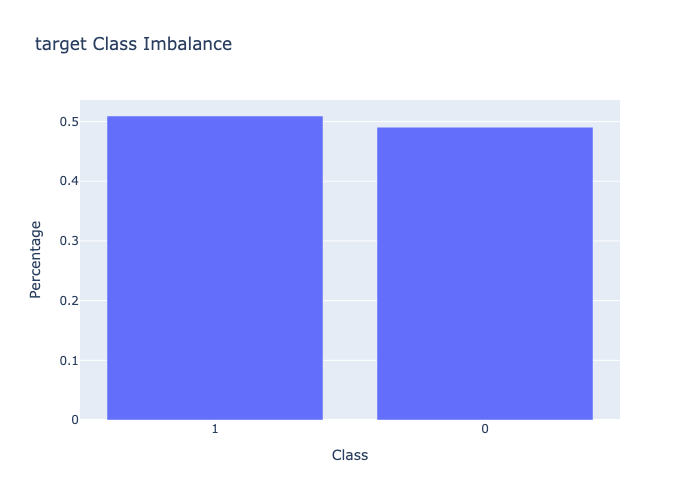

2026-04-20 10:09:20,550 - INFO(validmind.vm_models.result.result): Test driven block with result_id validmind.data_validation.ClassImbalance does not exist in model's document


In [34]:
# Class imbalance check
result = vm.tests.run_test(
    "validmind.data_validation.ClassImbalance",
    inputs={"dataset": vm_train_ds},
)
result.log()


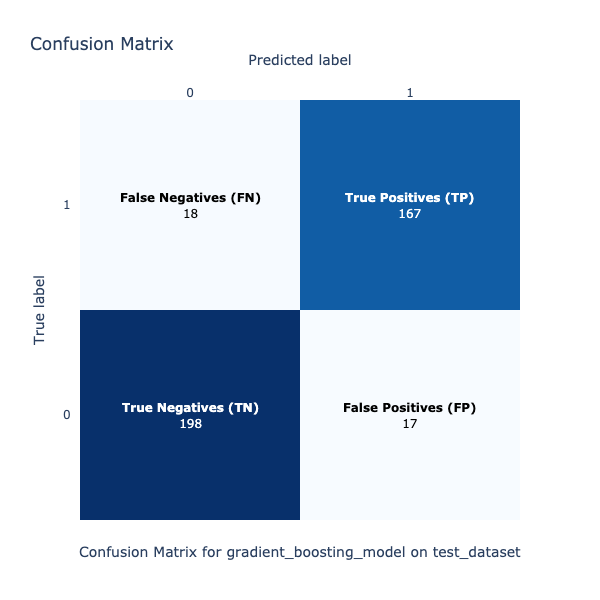

2026-04-20 10:09:27,460 - INFO(validmind.vm_models.result.result): Test driven block with result_id validmind.model_validation.sklearn.ConfusionMatrix does not exist in model's document


In [35]:
# Confusion matrix — validates model performance visualization
result = vm.tests.run_test(
    "validmind.model_validation.sklearn.ConfusionMatrix",
    inputs={"dataset": vm_test_ds, "model": vm_model},
)
result.log()


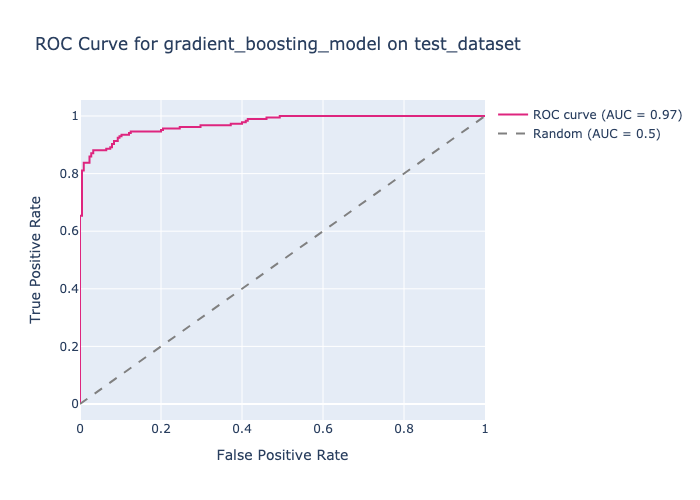

2026-04-20 10:09:31,104 - INFO(validmind.vm_models.result.result): Test driven block with result_id validmind.model_validation.sklearn.ROCCurve does not exist in model's document


In [36]:
# ROC curve
result = vm.tests.run_test(
    "validmind.model_validation.sklearn.ROCCurve",
    inputs={"dataset": vm_test_ds, "model": vm_model},
)
result.log()

In [37]:
# Feature importance
result = vm.tests.run_test(
    "validmind.model_validation.sklearn.FeatureImportance",
    inputs={"dataset": vm_train_ds, "model": vm_model},
)
result.log()

Feature 1,Feature 2,Feature 3
[is_active_member; 0.3064],[num_products; 0.1396],[has_credit_card; 0.0691]


2026-04-20 10:09:37,317 - INFO(validmind.vm_models.result.result): Test driven block with result_id validmind.model_validation.sklearn.FeatureImportance does not exist in model's document


## Step 10 — Run the full test suite

This runs the complete classifier documentation suite and sends all results to ValidMind in one call.

> This is the primary validation that results can be sent from a Databricks notebook environment.

2026-04-20 10:09:37,428 - ERROR(validmind.vm_models.test_suite.test): Failed to run test 'validmind.data_validation.DescriptiveStatistics': (ValueError) Cannot describe a DataFrame without columns
2026-04-20 10:09:37,575 - ERROR(validmind.vm_models.test_suite.test): Failed to run test 'validmind.data_validation.DatasetSplit': (MissingRequiredTestInputError) Missing required input: datasets.
2026-04-20 10:09:38,778 - ERROR(validmind.vm_models.test_suite.test): Failed to run test 'validmind.model_validation.sklearn.PrecisionRecallCurve': (ValueError) y_true takes value in {'0', '1'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.
2026-04-20 10:09:38,805 - ERROR(validmind.vm_models.test_suite.test): Failed to run test 'validmind.model_validation.sklearn.PopulationStabilityIndex': (MissingRequiredTestInputError) Missing required input: datasets.
2026-04-20 10:09:38,810 - ERROR(validmind.vm_models.test_suite.test): Failed to r

Name,Type,Count,Missing,Missing %,Distinct,Distinct %
age,Text,400,0,0.0,400,1.000
tenure,Text,400,0,0.0,400,1.000
balance,Text,400,0,0.0,400,1.000
geo_encoded,Text,400,0,0.0,400,1.000
credit_score,Text,400,0,0.0,400,1.000
num_products,Text,400,0,0.0,400,1.000
gender_encoded,Text,400,0,0.0,400,1.000
has_credit_card,Text,400,0,0.0,400,1.000
estimated_salary,Text,400,0,0.0,400,1.000
is_active_member,Text,400,0,0.0,400,1.000

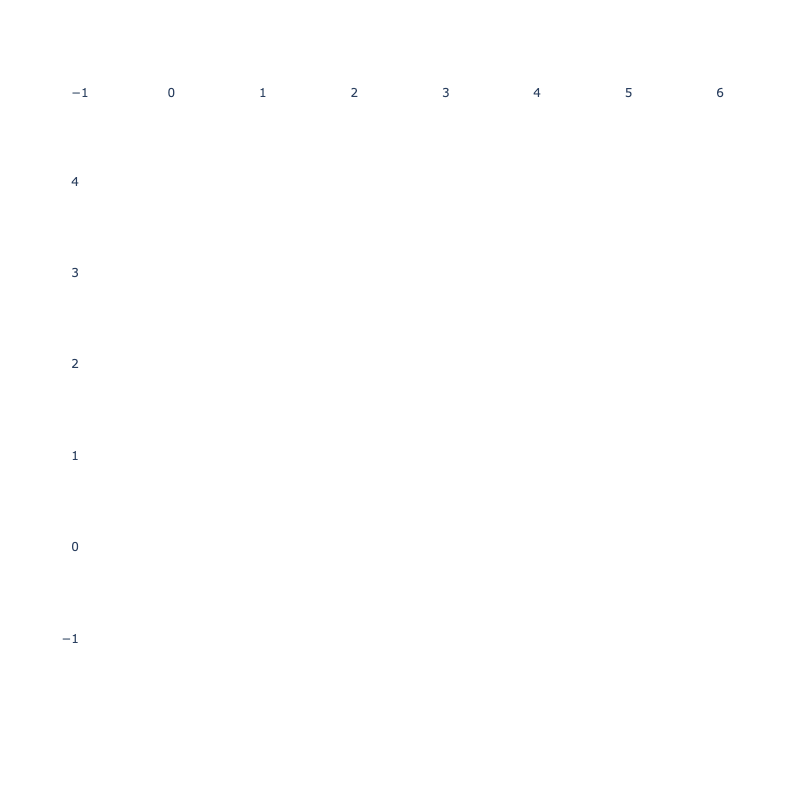
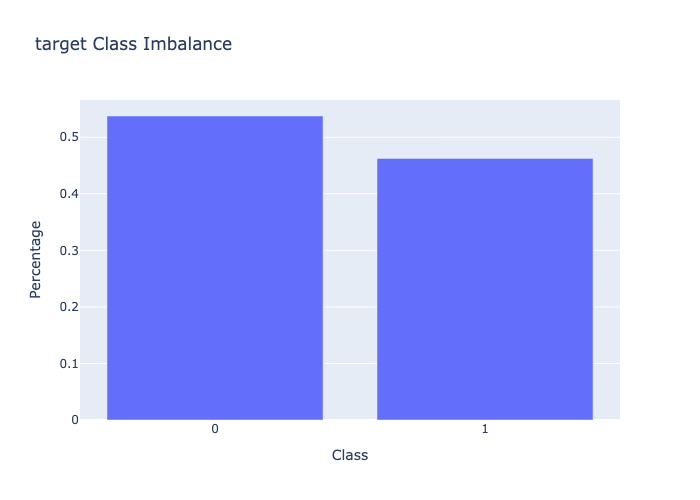
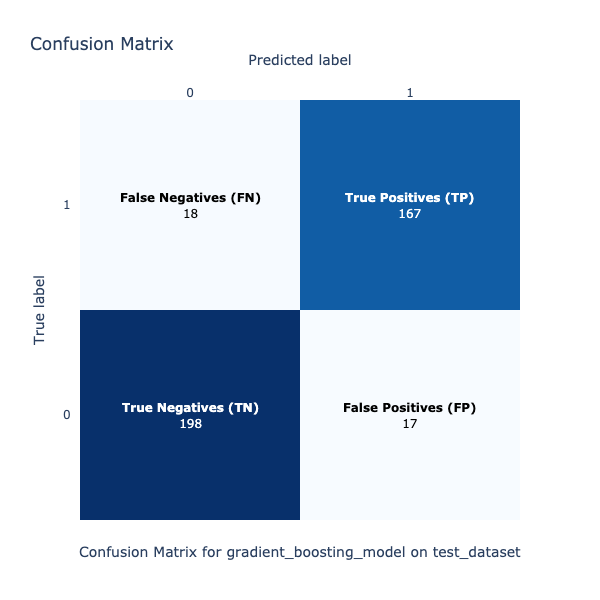
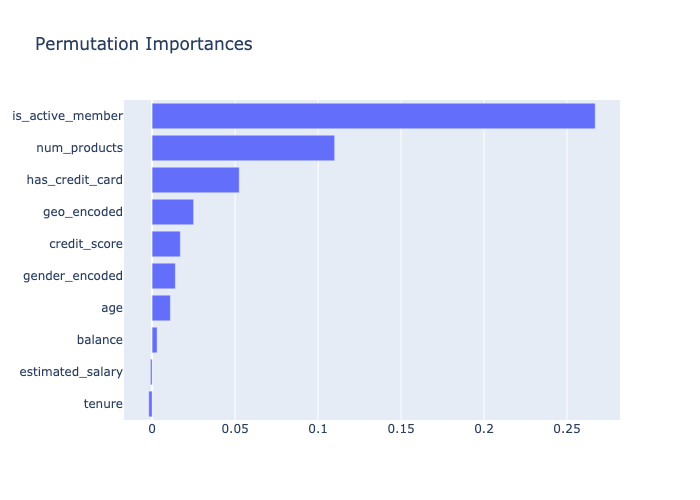
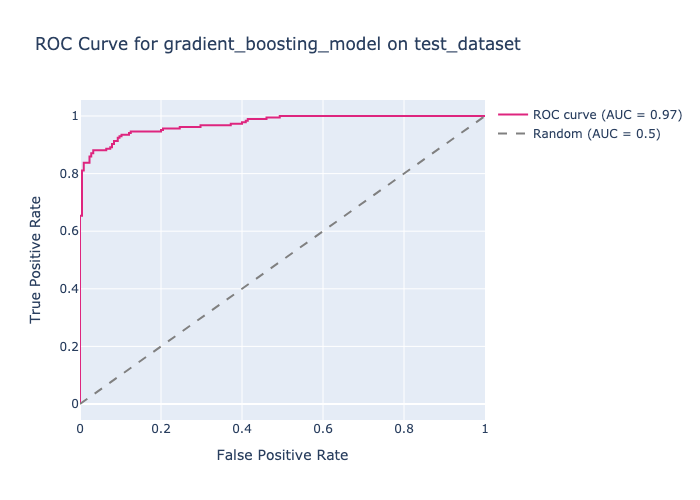

Full test suite completed and results sent to ValidMind Platform.


In [38]:
test_suite_result = vm.run_test_suite(
    "classifier_full_suite",
    inputs={
        "dataset": vm_test_ds,
        "model": vm_model,
        "train_dataset": vm_train_ds,
        "test_dataset": vm_test_ds,
    },
)
print('Full test suite completed and results sent to ValidMind Platform.')

## Step 11 — Verify results on the platform

1. Go to [ValidMind Platform](https://app.prod.validmind.ai) (or your local instance)
2. Navigate to **Model Inventory** → your model
3. Open the **Documentation** tab
4. Confirm that test results from this notebook appear

**Expected results visible on platform:**
- Dataset Description table
- Class Imbalance chart
- Confusion Matrix
- ROC Curve
- Feature Importance chart
- Full classifier suite results

---

## Troubleshooting

| Issue | Fix |
|-------|-----|
| `ModuleNotFoundError` after install | Re-run the `dbutils.library.restartPython()` cell |
| `ConnectionError` on `vm.init()` | Workspace may block outbound traffic — check network policy or use a cluster with internet access |
| `401 Unauthorized` on `vm.init()` | API key/secret are incorrect — copy credentials fresh from the platform |
| `numpy` version conflict | Pin with `%pip install -q validmind "numpy>=1.23,<2.0.0"` |
| `404` on dataset load | No Databricks table binding found — create one in Settings → Integrations → Databricks, then wait for sync |
| `row_data is empty` after binding created | Initial sync is still running — wait ~30 seconds and re-run Step 4 |
| Wrong columns / target not found | Update `TARGET_COLUMN` in Step 4 to match the actual target column in your UC table |
| Want to test without a binding | Set `USE_SYNTHETIC_FALLBACK = True` in Step 4 |